In [1]:
import numpy as np
import pandas as pd

df_ads = pd.read_csv('/kaggle/input/advertising-simple-dataset/advertising.csv')
df_ads.head()

,wechat,weibo,others,sales
0,304.4,93.6,294.4,9.7
1,1011.9,34.4,398.4,16.7
2,1091.1,32.8,295.2,17.3
3,85.5,173.6,403.2,7.0
4,1047.0,302.4,553.6,22.1


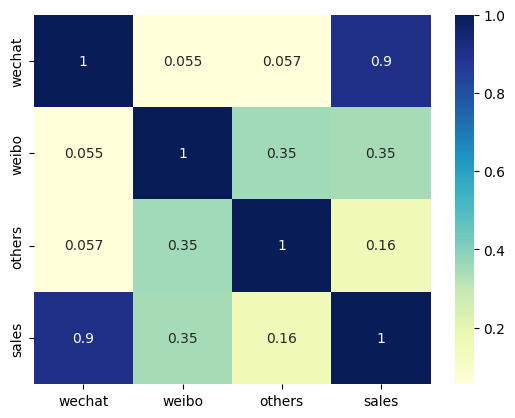

In [2]:
import matplotlib.pyplot as plt 
import seaborn as sns
# 对所有的标签和特征两两显示其相关性的热力图
sns.heatmap(df_ads.corr(), cmap="YlGnBu", annot=True)
plt.show()

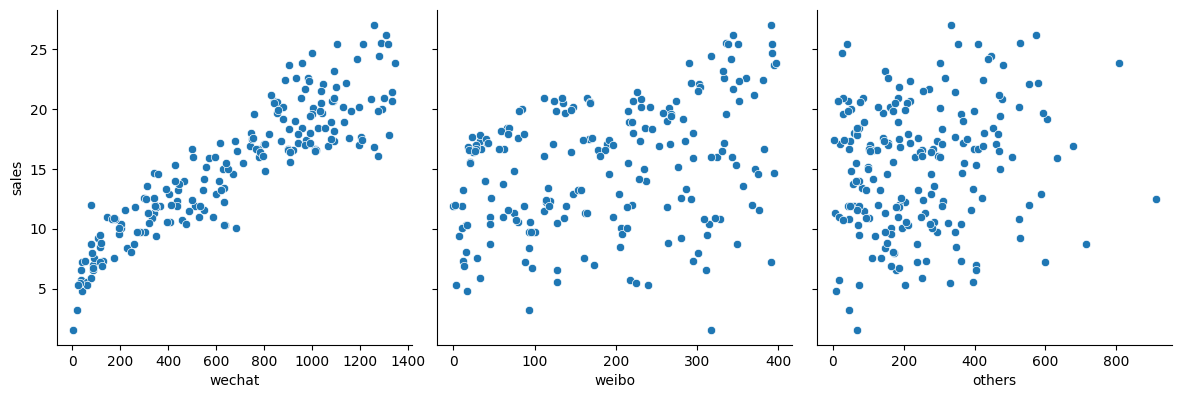

In [3]:
# 显示销售额和各种广告投放金额的散点图
sns.pairplot(df_ads,
            x_vars = ['wechat', 'weibo', 'others'],
            y_vars = 'sales', 
            height = 4, aspect = 1, kind = 'scatter')

plt.show()

In [4]:
# 构建特征集，只含有微信公众号广告投放金额的一个特征
X = np.array(df_ads.wechat)
# 构建标签集，销售额
y = np.array(df_ads.sales)
print("张量 X 的阶：", X.ndim)
print("张量 X 的形状：", X.shape)
print("张量 X 的内容：", X)

张量 X 的阶： 1
张量 X 的形状： (200,)
张量 X 的内容： [ 304.4 1011.9 1091.1   85.5 1047.   940.9 1277.2   38.2  342.6  347.6
  980.1   39.1   39.6  889.1  633.8  527.8  203.4  499.6  633.4  437.7
  334.  1132.   841.3  435.4  627.4  599.2  321.2  571.9  758.9  799.4
  314.   108.3  339.9  619.7  227.5  347.2  774.4 1003.3   60.1   88.3
 1280.4  743.9  805.4  905.    76.9 1088.8  670.2  513.7 1067.    89.2
  130.1  113.8  195.7 1000.1  283.5 1245.3  681.1  341.7  743.   976.9
 1308.6  953.7 1196.2  488.7 1027.4  830.8  984.6  143.3 1092.5  993.7
 1290.4  638.4  355.8  854.5    3.2  615.2   53.2  401.8 1348.6   78.3
 1188.9 1206.7  899.1  364.9  854.9 1099.7  909.1 1293.6  311.2  411.3
  881.3 1091.5   18.7  921.4 1214.4 1038.8  427.2  116.5  879.1  971.
  899.1  114.2   78.3   59.6  748.5  681.6  261.6 1083.8 1322.7  753.5
 1259.9 1080.2   33.2  909.1 1092.5 1208.5  766.2  467.3  611.1  202.5
   24.6  442.3 1301.3  314.9  634.7  408.1  560.1  503.7 1154.8 1130.2
  932.8  958.7 1044.2 1274.9  550.6 1259

In [5]:
# 通过 reshape 方法把向量转换为矩阵
X = X.reshape((len(X), 1))
# 通过 reshape 方法把向量转换为矩阵
y = y.reshape((len(y), 1))

print("张量 X 的阶：", X.ndim)
print("张量 X 的形状：", X.shape)
print("张量 X 的内容：", X)

张量 X 的阶： 2
张量 X 的形状： (200, 1)
张量 X 的内容： [[ 304.4]
 [1011.9]
 [1091.1]
 [  85.5]
 [1047. ]
 [ 940.9]
 [1277.2]
 [  38.2]
 [ 342.6]
 [ 347.6]
 [ 980.1]
 [  39.1]
 [  39.6]
 [ 889.1]
 [ 633.8]
 [ 527.8]
 [ 203.4]
 [ 499.6]
 [ 633.4]
 [ 437.7]
 [ 334. ]
 [1132. ]
 [ 841.3]
 [ 435.4]
 [ 627.4]
 [ 599.2]
 [ 321.2]
 [ 571.9]
 [ 758.9]
 [ 799.4]
 [ 314. ]
 [ 108.3]
 [ 339.9]
 [ 619.7]
 [ 227.5]
 [ 347.2]
 [ 774.4]
 [1003.3]
 [  60.1]
 [  88.3]
 [1280.4]
 [ 743.9]
 [ 805.4]
 [ 905. ]
 [  76.9]
 [1088.8]
 [ 670.2]
 [ 513.7]
 [1067. ]
 [  89.2]
 [ 130.1]
 [ 113.8]
 [ 195.7]
 [1000.1]
 [ 283.5]
 [1245.3]
 [ 681.1]
 [ 341.7]
 [ 743. ]
 [ 976.9]
 [1308.6]
 [ 953.7]
 [1196.2]
 [ 488.7]
 [1027.4]
 [ 830.8]
 [ 984.6]
 [ 143.3]
 [1092.5]
 [ 993.7]
 [1290.4]
 [ 638.4]
 [ 355.8]
 [ 854.5]
 [   3.2]
 [ 615.2]
 [  53.2]
 [ 401.8]
 [1348.6]
 [  78.3]
 [1188.9]
 [1206.7]
 [ 899.1]
 [ 364.9]
 [ 854.9]
 [1099.7]
 [ 909.1]
 [1293.6]
 [ 311.2]
 [ 411.3]
 [ 881.3]
 [1091.5]
 [  18.7]
 [ 921.4]
 [1214.4]
 [1038.8]


In [6]:
# 将数据集进行80%（训练集）和20%（测试集）的分割
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, random_state = 0)

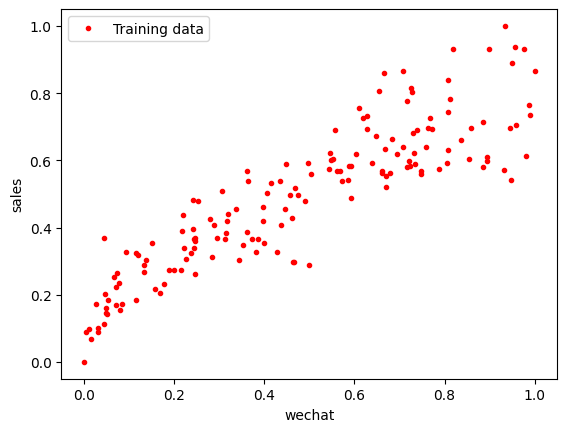

In [7]:
# 定义归一化函数，进行数据压缩
def scaler(train, test):
    min = train.min(axis = 0)
    max = train.max(axis = 0)
    gap = max - min
    train -= min
    train /= gap
    test -= min
    test /= gap
    
    return train, test

# 对特征归一化
X_train, X_test = scaler(X_train, X_test)
# 对标签也归一化
y_train, y_test = scaler(y_train, y_test)

# 用之前已经导入的matplotlib.pyplot中的 plot 方法显示散点图
plt.plot(X_train, y_train, 'r.', label = 'Training data')
plt.xlabel('wechat')
plt.ylabel('sales')
plt.legend()
plt.show()

In [8]:
def loss_function(X, y, weight, bias):
    y_hat = weight * X + bias
    loss = y_hat - y 
    cost = np.sum(loss**2)/(2*len(X))

    return cost

print("当权重为 5，偏置为 3 时，损失为：",
    loss_function(X_train, y_train, weight = 5, bias = 3))
print("当权重为 100，偏置为 1 时，损失为：",
    loss_function(X_train, y_train, weight = 100, bias = 1))

当权重为 5，偏置为 3 时，损失为： 12.79639097078006
当权重为 100，偏置为 1 时，损失为： 1577.9592615030556


In [9]:
def gradient_decent(X, y, w, b, lr, iter):
    # 初始化记录梯度下降过程中损失的数组
    l_history = np.zeros(iter)
    # 初始化记录梯度下降过程中权重的数组
    w_history = np.zeros(iter)
    # 初始化记录梯度下降过程中偏置的数组
    b_history = np.zeros(iter)

    # 进行梯度下降的迭代，就是下多少级台阶
    for i in range(iter):
        y_hat = w * X + b 
        loss = y_hat - y 
        # 对权重求导
        derivative_weight = X.T.dot(loss) / len(X)
        # 对偏置求导
        derivative_bias = sum(loss) * 1/len(X)
        # 结合学习速率更新权重
        w = w - lr * derivative_weight
        # 结合学习速率更新偏置
        b = b - lr * derivative_bias
        # 梯度下降过程中损失的历史记录
        l_history[i] = loss_function(X, y, w, b)
        # 梯度下降过程中权重的历史记录
        w_history[i] = w
        # 梯度下降过程中偏置的历史记录
        b_history[i] = b

    return l_history, w_history, b_history

iterations = 100
alpha = 1
weight = -5
bias = 3

print('当前损失：', loss_function(X_train, y_train, weight, bias))

当前损失： 1.343795534906634


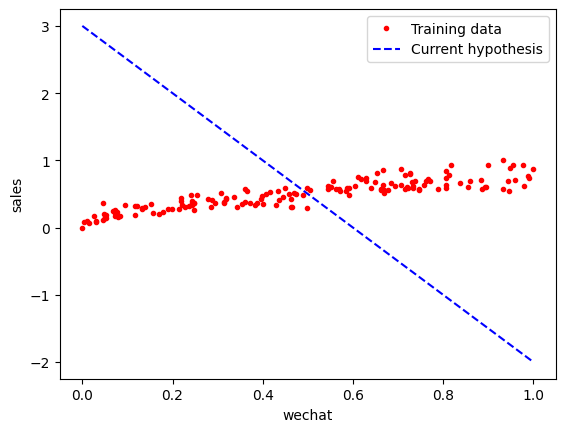

In [10]:
plt.plot(X_train, y_train, 'r.', label = 'Training data')
# X 值域
line_X = np.linspace(X_train.min(), X_train.max(), 500)
line_y = [weight * x + bias for x in line_X]
plt.plot(line_X, line_y, 'b--', label = 'Current hypothesis')
plt.xlabel('wechat')
plt.ylabel('sales')
plt.legend()
plt.show()

In [11]:
loss_history, weight_history, bias_history = gradient_decent(
    X_train, y_train, weight, bias, alpha, iterations
)

<ipython-input-9-02fa0a77783a>:24: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  w_history[i] = w
<ipython-input-9-02fa0a77783a>:26: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  b_history[i] = b


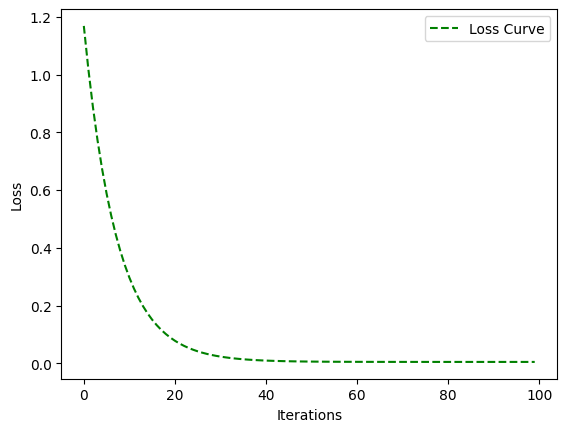

In [12]:
plt.plot(loss_history, 'g--', label = 'Loss Curve')
plt.xlabel('Iterations')
plt.ylabel('Loss')
plt.legend()
plt.show()

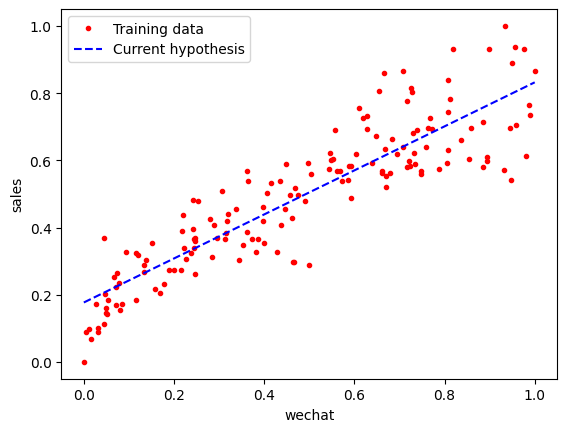

In [13]:
plt.plot(X_train, y_train, 'r.', label = 'Training data')
line_X = np.linspace(X_train.min(), X_train.max(), 500)
line_y = [weight_history[-1] * x + bias_history[-1] for x in line_X]
plt.plot(line_X, line_y, 'b--', label='Current hypothesis')
plt.xlabel('wechat')
plt.ylabel('sales')
plt.legend()
plt.show()

In [14]:
print('测试集损失：', loss_function(X_test, y_test, weight_history[-1], bias_history[-1]))

测试集损失： 0.00458180938024721
